#  Relatório de Análise Exploratória (Camada Raw)
**Objetivo:** Diagnosticar a qualidade dos dados brutos do CEAP (Cota para o Exercício da Atividade Parlamentar) antes do processamento ETL.
**Dataset:** `deputies_dataset.csv`

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Carga de Dados
df = pd.read_csv('deputies_dataset.csv')

# Conversão forçada para numérico 
df['receipt_value_num'] = pd.to_numeric(df['receipt_value'], errors='coerce')

print(f"Volume de Dados: {df.shape[0]} linhas e {df.shape[1]} colunas.")

Volume de Dados: 3014902 linhas e 11 colunas.


## 1. Análise de Extremos (Outliers)
Neste gráfico, utilizamos um **Boxplot** para visualizar a dispersão dos valores dos reembolsos.
* **Hipótese:** Existem valores exorbitantes que fogem do padrão de gastos parlamentares (almoços, táxis, passagens).
* **Diagnóstico:** A presença de pontos isolados (outliers) na parte superior do gráfico indica notas fiscais com valores muito acima da média, sugerindo necessidade de auditoria ou erro de digitação.

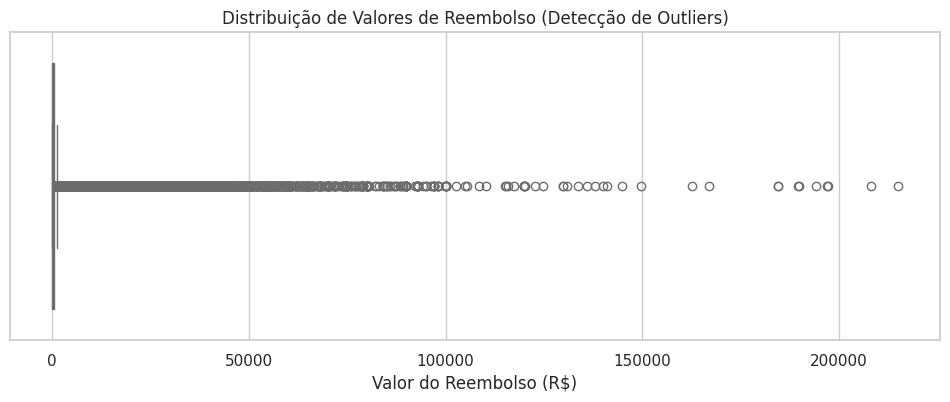

In [4]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=df['receipt_value_num'], color='salmon')
plt.title('Distribuição de Valores de Reembolso (Detecção de Outliers)')
plt.xlabel('Valor do Reembolso (R$)')
plt.show()

## 2. Completude dos Dados (Valores Nulos)
Utilizamos um **Mapa de Calor (Heatmap)** para identificar visualmente onde estão os dados faltantes.
* **Foco:** Coluna `receipt_social_security_number` (CPF/CNPJ do fornecedor).
* **Diagnóstico:** As linhas brancas/claras indicam ausência de dados. A alta incidência de nulos nesta coluna compromete a rastreabilidade do gasto, pois não sabemos para qual empresa o dinheiro foi.

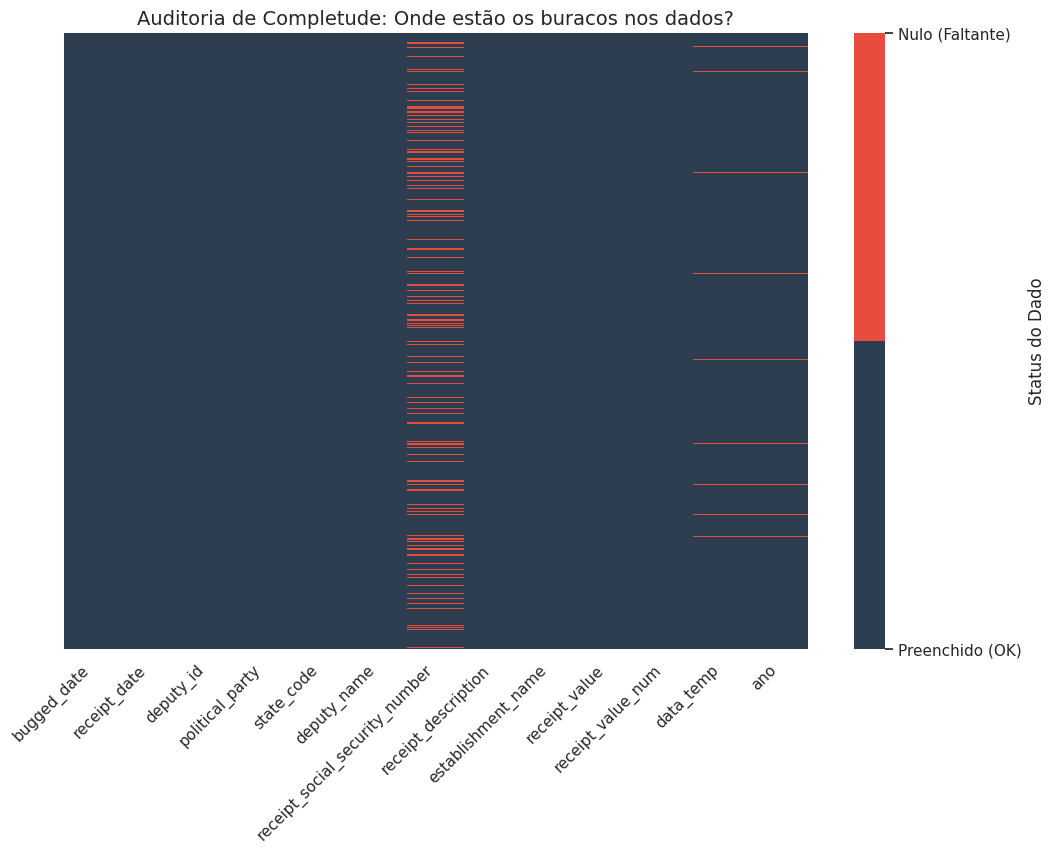

--- Diagnóstico Numérico ---
Total de Recibos sem CNPJ/CPF identificado: 520.952
Representatividade do problema: 17.3% da base total.


In [14]:
# Importando ferramenta para criar cores personalizadas
from matplotlib.colors import ListedColormap

plt.figure(figsize=(12, 8)) # Aumentamos um pouco a altura

# 1. Criando um mapa de cores personalizado (Azul Profundo para OK, Vermelho Vivo para Nulo)
# O primeiro código é um azul escuro (#2c3e50), o segundo é vermelho (#e74c3c)
my_cmap = ListedColormap(['#2c3e50', '#e74c3c'])

# Pegamos a amostra
amostra_heatmap = df.sample(10000)

# 2. Gerando o gráfico com as novas cores e adicionando a legenda (cbar=True)
ax = sns.heatmap(amostra_heatmap.isnull(),
                 cbar=True,
                 cbar_kws={'label': 'Status do Dado', 'ticks': [0, 1]}, # Configura a legenda
                 yticklabels=False, # Esconde os números das linhas (não precisa)
                 cmap=my_cmap)

# Ajustando os rótulos da legenda para ficar claro
cbar = ax.collections[0].colorbar
cbar.set_ticklabels(['Preenchido (OK)', 'Nulo (Faltante)'])

# 3. Melhorando os textos do eixo X (Inclinando 45 graus)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.title('Auditoria de Completude: Onde estão os buracos nos dados?', fontsize=14)

plt.show()

# Dado numérico para complementar (Mantivemos este print pois é importante)
nulos_cnpj = df['receipt_social_security_number'].isnull().sum()
print(f"--- Diagnóstico Numérico ---")
print(f"Total de Recibos sem CNPJ/CPF identificado: {nulos_cnpj:,}".replace(',', '.'))
print(f"Representatividade do problema: {nulos_cnpj/len(df):.1%} da base total.")

## 3. Consistência Temporal
Tentativa de converter a coluna de datas e plotar a distribuição por ano.
* **Diagnóstico:** O gráfico abaixo exibe a quantidade de reembolsos por ano. Barras em anos muito antigos ou futuros indicam "lixo" temporal que precisará ser filtrado na camada Silver.
* **Problema Identificado:** A coluna `receipt_date` é originalmente texto (`object`), o que permite datas inválidas.

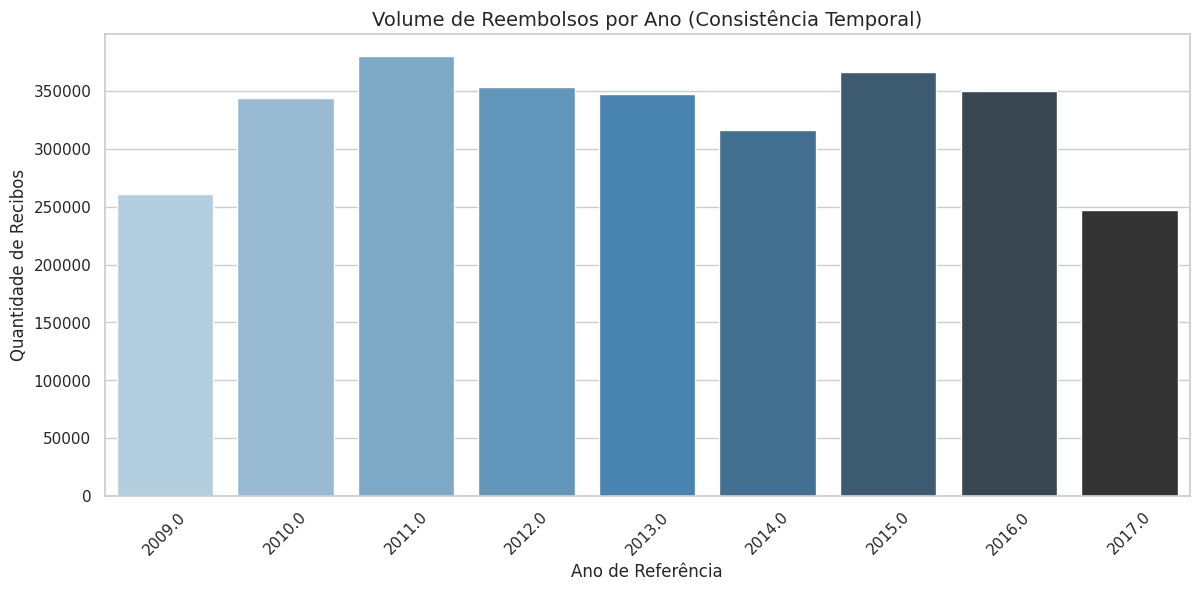

--- Diagnóstico Temporal ---
 Período identificado: De 2009 até 2017
 Datas ilegíveis (Erro de formato/texto sujo): 49531 registros
OBS: Se 'Datas ilegíveis' for 0, significa que o conteúdo das datas está limpo, apenas o tipo de dado (dtype) estava errado.


In [16]:
# Tenta converter para data, transformando erros em NaT (Not a Time)
df['data_temp'] = pd.to_datetime(df['receipt_date'], errors='coerce')

# Extrai o ano da data convertida
df['ano'] = df['data_temp'].dt.year


df_visual = df[(df['ano'] > 2008) & (df['ano'] <= 2024)]

plt.figure(figsize=(14, 6))

sns.countplot(x='ano', 
              data=df_visual, 
              hue='ano', 
              legend=False, 
              palette='Blues_d') # Palette deixa um degradê azul bonito

plt.title('Volume de Reembolsos por Ano (Consistência Temporal)', fontsize=14)
plt.xlabel('Ano de Referência', fontsize=12)
plt.ylabel('Quantidade de Recibos', fontsize=12)
plt.xticks(rotation=45)
plt.show()

min_ano = df['ano'].min()
max_ano = df['ano'].max()
datas_ilegiveis = df['data_temp'].isnull().sum() - df['receipt_date'].isnull().sum() 
org
print(f"--- Diagnóstico Temporal ---")
print(f" Período identificado: De {min_ano:.0f} até {max_ano:.0f}")
print(f" Datas ilegíveis (Erro de formato/texto sujo): {datas_ilegiveis} registros")
print(f"OBS: Se 'Datas ilegíveis' for 0, significa que o conteúdo das datas está limpo, apenas o tipo de dado (dtype) estava errado.")

## 4. Indicadores de Erro do Sistema (`bugged_date`)
O dataset original possui uma coluna de controle interna chamada `bugged_date`. Esta é uma **flag binária** (0 ou 1) gerada pelo sistema da Câmara dos Deputados.

* **O que ela significa?**
    * `0`: O registro foi processado corretamente na origem.
    * `1`: O registro contém anomalias graves de formatação (geralmente datas corrompidas ou caracteres inválidos) identificadas pelo próprio sistema fonte.
* **Objetivo da Análise:** Quantificar o volume de dados que já chegam "condenados".
* **Critério de Qualidade:** Qualquer valor diferente de 0% indica necessidade de limpeza (drop) imediata no ETL.

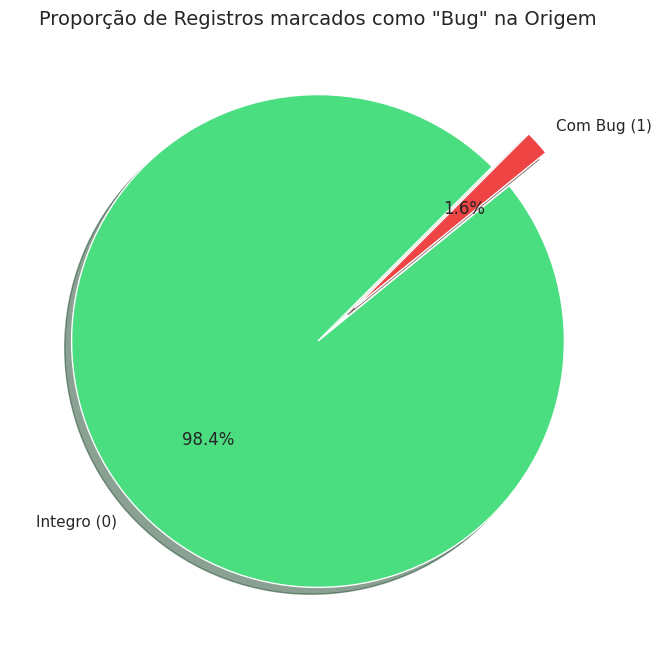

--- Diagnóstico Numérico ---
Total de linhas marcadas com bug: 49531 registros.
Representatividade: 1.6% da base.


In [17]:
import matplotlib.pyplot as plt

# Preparando os dados
contagem = df['bugged_date'].value_counts()
labels = ['Integro (0)', 'Com Bug (1)']
colors = ['#4ade80', '#ef4444'] # Verde e Vermelho 
explode = (0, 0.2)  #separa a fatia vermelha 

plt.figure(figsize=(8, 8))
plt.pie(contagem, 
        labels=labels, 
        colors=colors, 
        explode=explode, 
        autopct='%1.1f%%', # Mostra a porcentagem 
        shadow=True, 
        startangle=45)

plt.title('Proporção de Registros marcados como "Bug" na Origem', fontsize=14)
plt.show()

# Cálculos para a conclusão
total_bugs = contagem.get(1, 0)
total_linhas = len(df)
print(f"--- Diagnóstico Numérico ---")
print(f"Total de linhas marcadas com bug: {total_bugs} registros.")
print(f"Representatividade: {total_bugs/total_linhas:.1%} da base.")

## 5. Auditoria de Materialidade (Top 10 Despesas)
Análise de Pareto para identificar quais categorias consomem a maior parte dos recursos públicos.

* **Objetivo de Negócio:** Identificar os "Ofensores de Custo". As 3 primeiras categorias geralmente representam a maior parte do orçamento.
* **Diagnóstico de Qualidade:** Verificar a 'Padronização de Strings'.
    * *O que procurar:* Categorias duplicadas com grafias diferentes (ex: "Emissão de Bilhete" vs "Emissão Bilhete Aéreo"). Se isso ocorrer, os valores ficam diluídos e o ranking fica errado, exigindo tratamento de texto (String Matching) na camada Silver.

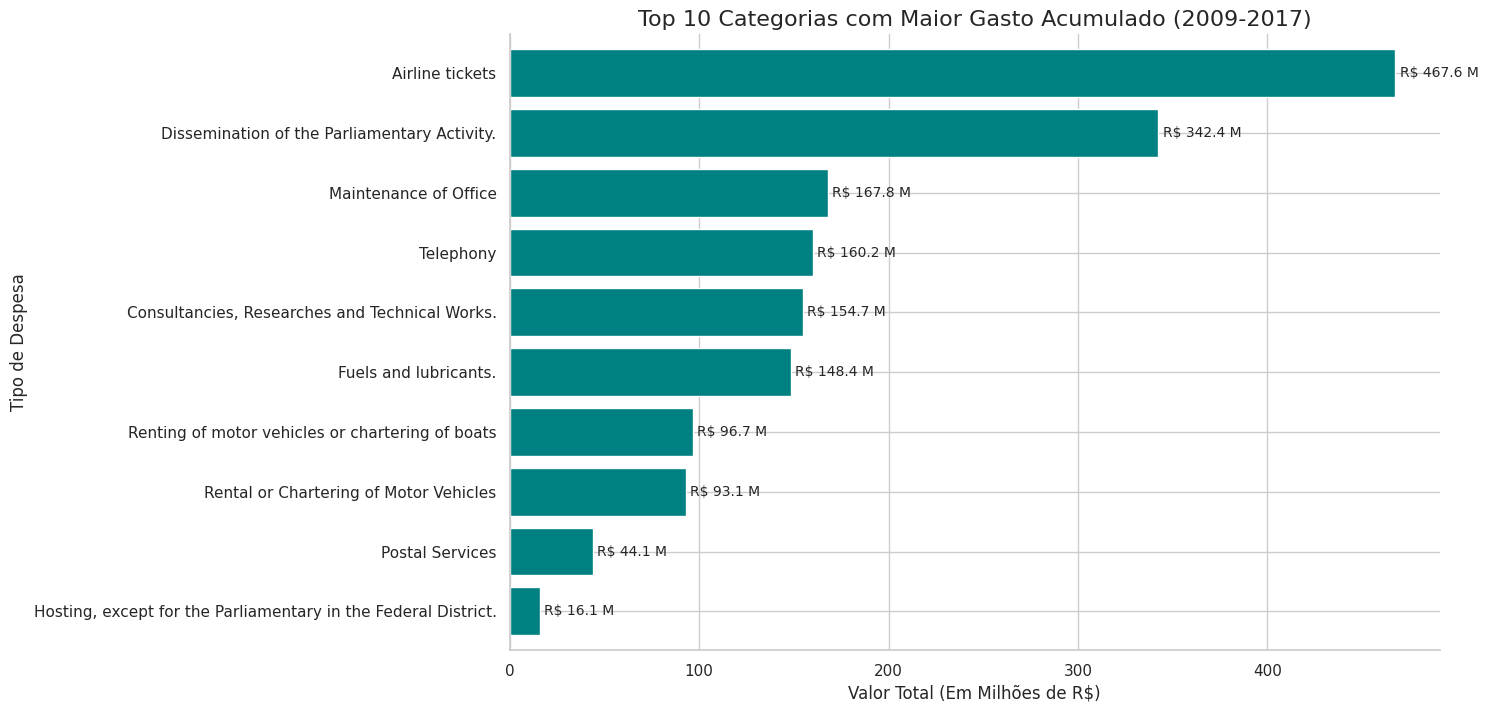

--- Validação de Categorias ---
Total de categorias únicas encontradas: 21
Categorias no Top 10:
 ['Hosting, except for the Parliamentary in the Federal District.', 'Postal Services', 'Rental or Chartering of Motor Vehicles', 'Renting of motor vehicles or chartering of boats', 'Fuels and lubricants.', 'Consultancies, Researches and Technical Works.', 'Telephony', 'Maintenance of Office', 'Dissemination of the Parliamentary Activity.', 'Airline tickets']


In [18]:
# Recalculando os dados
top_categorias = df.groupby('receipt_description')['receipt_value_num'].sum().nlargest(10).sort_values()

# Convertendo de "Reais" para "Milhões de Reais"
top_categorias_milhoes = top_categorias / 1_000_000

plt.figure(figsize=(12, 8))

# Plotamos usando a escala de Milhões
ax = top_categorias_milhoes.plot(kind='barh', color='teal', width=0.8)

plt.title('Top 10 Categorias com Maior Gasto Acumulado (2009-2017)', fontsize=16)
plt.xlabel('Valor Total (Em Milhões de R$)', fontsize=12)
plt.ylabel('Tipo de Despesa', fontsize=12)

# Adiciona o rótulo de dados na ponta de cada barra 
# O loop percorre cada barra e escreve o texto
for container in ax.containers:
    ax.bar_label(container, fmt='R$ %.1f M', padding=3, fontsize=10)


sns.despine()

plt.show()

# Print para validar se existe duplicação de texto (ex: Taxi vs Táxi)
print("--- Validação de Categorias ---")
print(f"Total de categorias únicas encontradas: {df['receipt_description'].nunique()}")
print("Categorias no Top 10:\n", top_categorias.index.tolist())

## 6. Distribuição de Custos por Agremiação Partidária
Nesta seção, realizamos a agregação total dos valores reembolsados, segmentados pela sigla do partido (`political_party`).

* **Perspectiva de Negócio:** Identificar quais partidos consomem a maior fatia do orçamento parlamentar (Custo Acumulado).
* **Diagnóstico de Qualidade (Data Profiling):** Verificar a **Padronização de Entidades**.
    * *Problema Potencial:* Em dados brutos (*Raw*), é comum encontrar a mesma entidade escrita de formas diferentes (ex: `PCdoB`, `PCDOB`, `PC do B`).
    * *Ação Necessária:* Se o gráfico ou a lista de siglas mostrar duplicidade, será necessário aplicar uma etapa de **Normalização de Strings** ou enriquecimento via dicionário auxiliar (Tabela V2) na camada Silver.

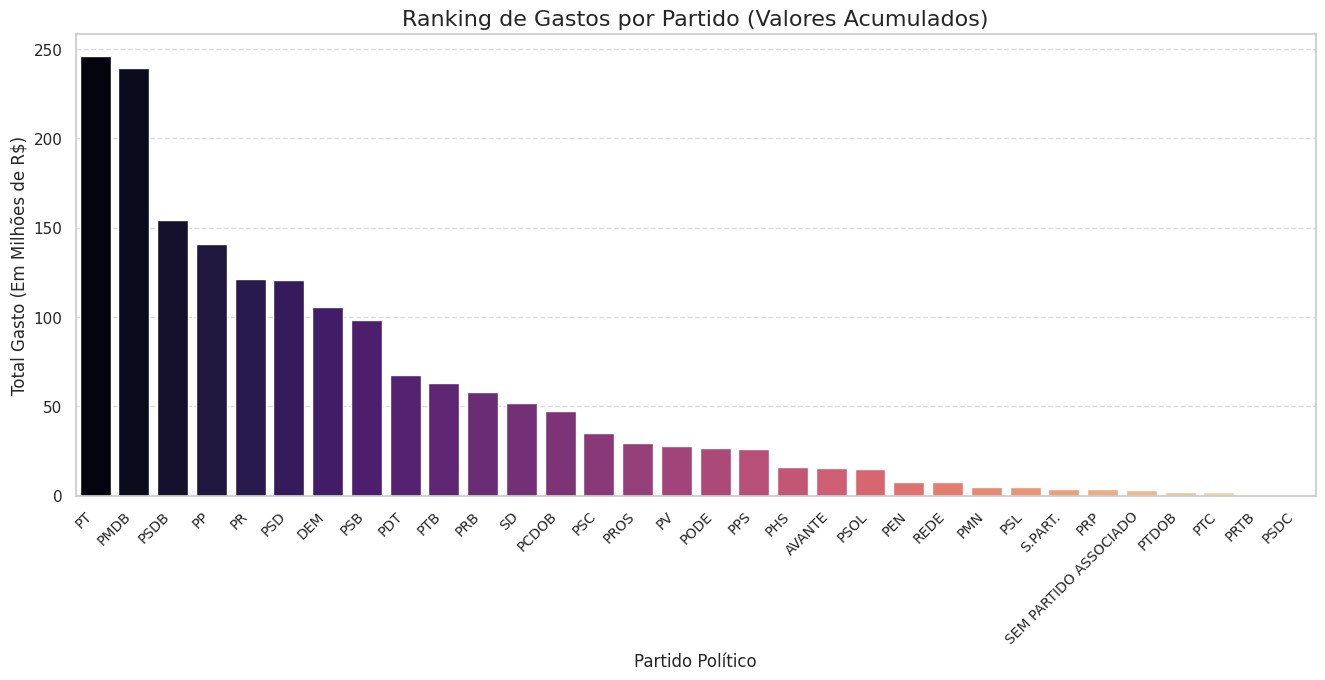

--- Diagnóstico de Partidos ---
Total de siglas encontradas: 32
Os 5 maiores gastadores: ['PT', 'PMDB', 'PSDB', 'PP', 'PR']


In [19]:
# Recalculando os dados
gastos_partido = df.groupby('political_party')['receipt_value_num'].sum().sort_values(ascending=False)

# Convertendo para Milhões
gastos_partido_milhoes = gastos_partido / 1_000_000

plt.figure(figsize=(16, 6)) #largura 


# 2. DADOS EM MILHÕES
sns.barplot(x=gastos_partido_milhoes.index, 
            y=gastos_partido_milhoes.values, 
            hue=gastos_partido_milhoes.index, 
            legend=False, 
            palette='magma')

plt.title('Ranking de Gastos por Partido (Valores Acumulados)', fontsize=16)
plt.ylabel('Total Gasto (Em Milhões de R$)', fontsize=12)
plt.xlabel('Partido Político', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


# Mostramos quantas siglas diferentes existem. Se for muito maior que o número real de partidos (aprox 30-35), tem lixo.
qtd_partidos = df['political_party'].nunique()
print(f"--- Diagnóstico de Partidos ---")
print(f"Total de siglas encontradas: {qtd_partidos}")
print(f"Os 5 maiores gastadores: {gastos_partido_milhoes.head(5).index.tolist()}")

## 7. Ranking de Gastos Acumulados por Parlamentar (Top 10)
Diferente da análise de outliers (que foca em notas fiscais isoladas), este gráfico apresenta a Soma Total dos reembolsos solicitados por cada deputado ao longo de todo o período.

* **Objetivo de Negócio:** Identificar os "Campeões de Gastos".
* **Análise de Correlação:** É importante cruzar este ranking com a lista de outliers. Se um deputado está no Top 10 acumulado apenas porque teve uma ou duas notas fiscais milionárias (outliers), isso indica uma distorção grave que precisa ser tratada no ETL.

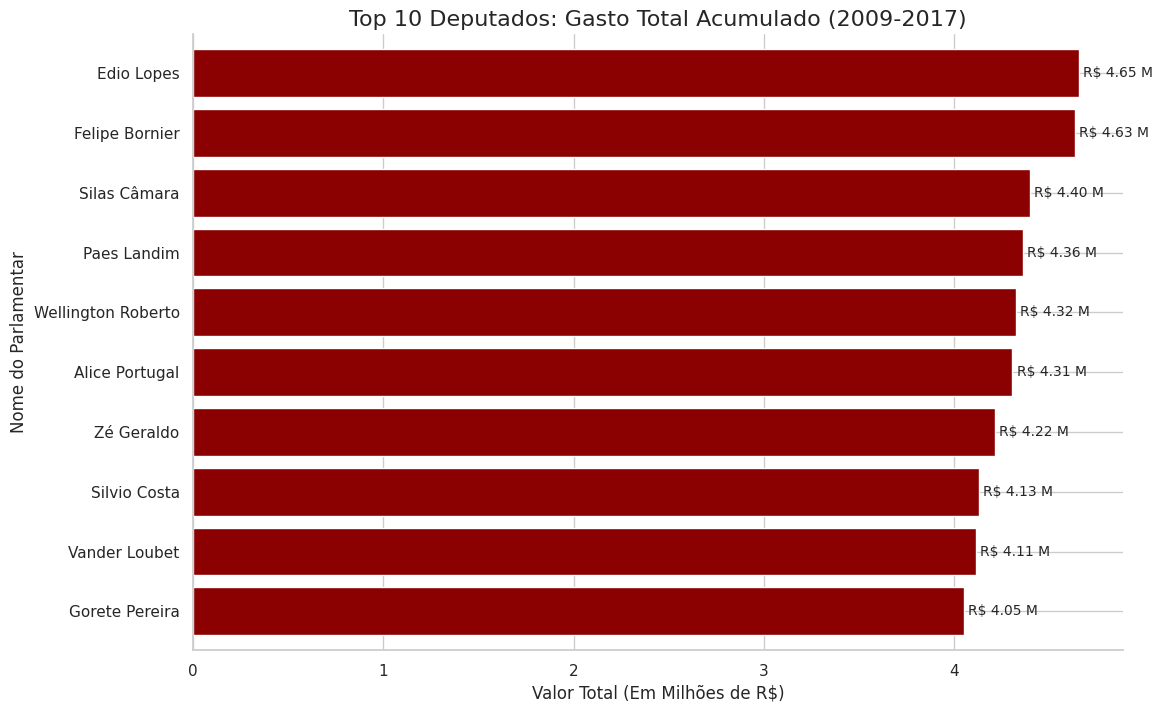

--- Validação ---
O deputado que mais gastou (Top 1) consumiu R$ 4,653,376.00 no total.


In [20]:
# Agrupa por nome e soma
top_deputados = df.groupby('deputy_name')['receipt_value_num'].sum().nlargest(10).sort_values()

# Milhões
top_deputados_milhoes = top_deputados / 1_000_000

plt.figure(figsize=(12, 8))

# Plotagem
ax = top_deputados_milhoes.plot(kind='barh', color='#8b0000', width=0.8) # Vermelho escuro

plt.title('Top 10 Deputados: Gasto Total Acumulado (2009-2017)', fontsize=16)
plt.xlabel('Valor Total (Em Milhões de R$)', fontsize=12)
plt.ylabel('Nome do Parlamentar', fontsize=12)

# valores na ponta das barras
for container in ax.containers:
    ax.bar_label(container, fmt='R$ %.2f M', padding=3, fontsize=10)

# Remove bordas desnecessárias
sns.despine()

plt.show()

print("--- Validação ---")
print(f"O deputado que mais gastou (Top 1) consumiu R$ {top_deputados.max():,.2f} no total.")

## 8. Análise de Ticket Médio (Custo por Nota)
Diferente da visão de montante total, aqui analisamos o **Valor Médio** de cada recibo apresentado (`Mean`).

* **Conceito:** O "Ticket Médio" revela o comportamento de gasto unitário.
* **Diagnóstico de Anomalias:**
    * Categorias operacionais: Táxi, Combustível, Correios devem ter ticket médio baixo < R$ 200.
  
    * Categorias de serviço especializado: Consultorias, Locação de Veículos/Aeronaves naturalmente possuem ticket médio alto > R$ 5.000.
    * **Ponto de Atenção:** Se uma categoria simples apresentar ticket médio elevado, há forte indício de superfaturamento (*Overpricing*).

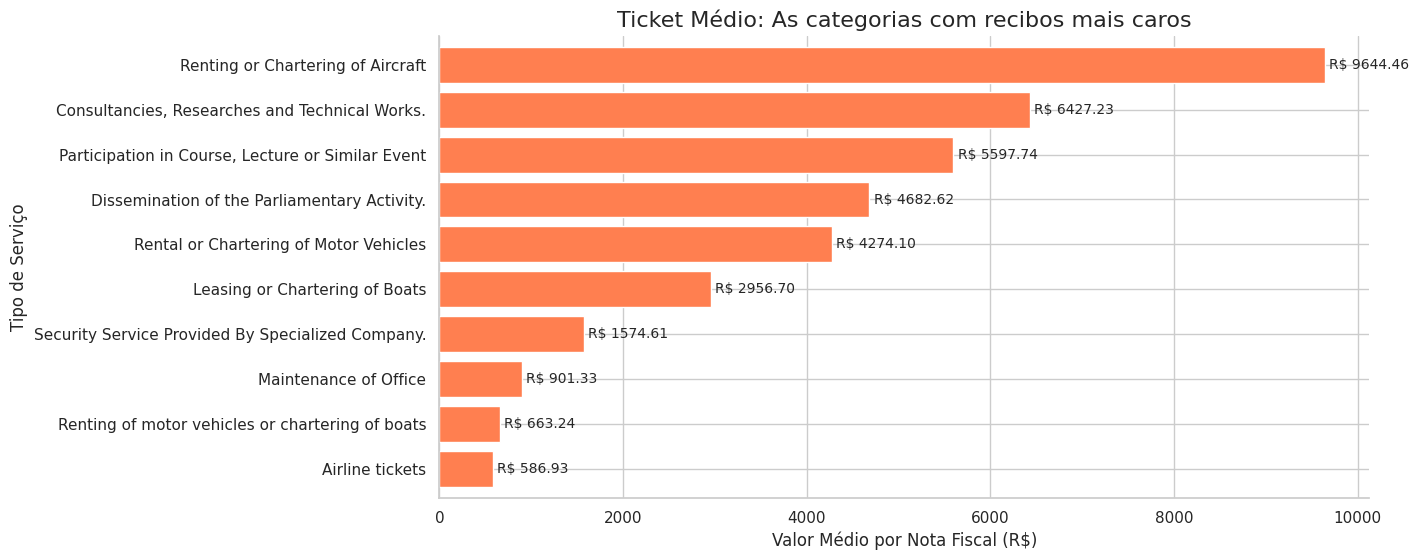

--- Análise Rápida ---
A categoria mais cara tem média de R$ 9644.46 por nota.


In [21]:
# Calculando a média
media_servico = df.groupby('receipt_description')['receipt_value_num'].mean().nlargest(10).sort_values()

plt.figure(figsize=(12, 6))

# Plotagem 
ax = media_servico.plot(kind='barh', color='#ff7f50', width=0.8)

plt.title('Ticket Médio: As categorias com recibos mais caros', fontsize=16)
plt.xlabel('Valor Médio por Nota Fiscal (R$)', fontsize=12)
plt.ylabel('Tipo de Serviço', fontsize=12)

# Adiciona o valor exato
for container in ax.containers:
    ax.bar_label(container, fmt='R$ %.2f', padding=3, fontsize=10)

sns.despine() 
plt.show()

print("--- Análise Rápida ---")
print(f"A categoria mais cara tem média de R$ {media_servico.max():.2f} por nota.")

## 9. Distribuição Geográfica dos Gastos (Por Estado)
Soma total dos reembolsos agrupados pela Unidade Federativa (`state_code`).

* **Objetivo de Negócio:** Analisar a representatividade regional dos gastos. Estados com bancadas maiores (SP, MG) tendem a gastar mais.
* **Auditoria de Qualidade (Integridade de Domínio):**
    * O Brasil possui 27 Unidades Federativas (26 estados + DF).
    * **O que buscar:** Barras com siglas estranhas (ex: "XX", "NA" ou nulos). Se aparecer qualquer coisa diferente das siglas oficiais (SP, RJ, etc.), temos um erro de consistência que o ETL precisará corrigir.

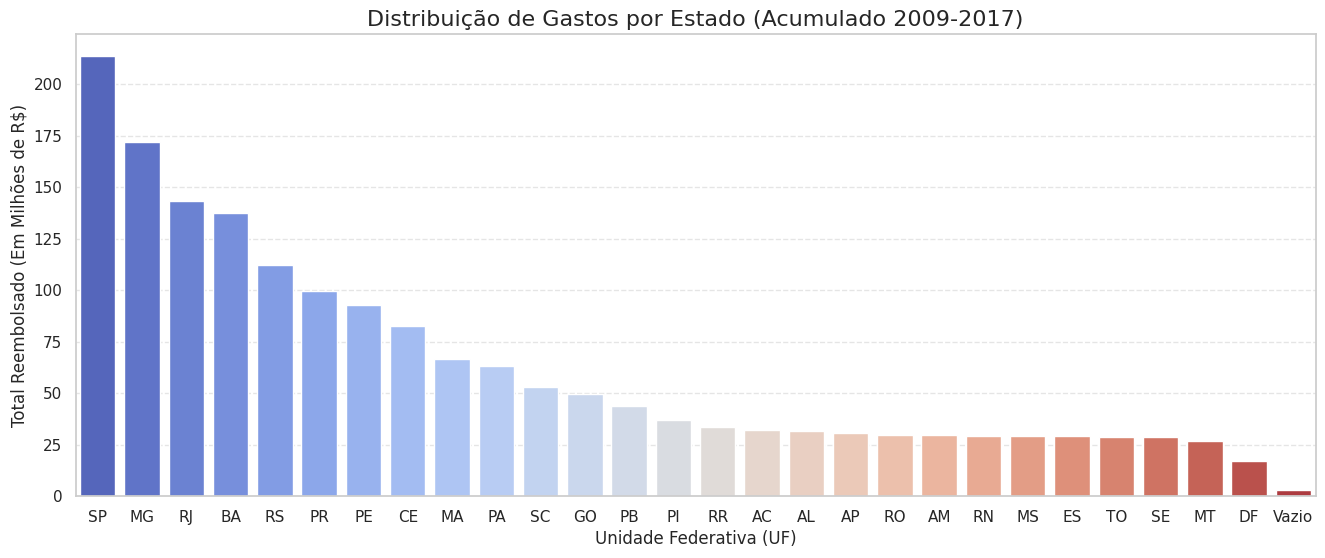

--- Diagnóstico Geográfico ---
Total de UFs encontradas: 28
 ATENÇÃO: Encontradas siglas inválidas: ['Vazio']


In [22]:
# Agrupando e ordenando
gastos_estado = df.groupby('state_code')['receipt_value_num'].sum().sort_values(ascending=False)

# Convertendo para Milhões 
gastos_estado_milhoes = gastos_estado / 1_000_000

plt.figure(figsize=(16, 6))

#hue=gastos_estado.index e legend=False
sns.barplot(x=gastos_estado_milhoes.index, 
            y=gastos_estado_milhoes.values, 
            hue=gastos_estado_milhoes.index, # O pulo do gato pro aviso sumir
            legend=False,
            palette='coolwarm')

plt.title('Distribuição de Gastos por Estado (Acumulado 2009-2017)', fontsize=16)
plt.ylabel('Total Reembolsado (Em Milhões de R$)', fontsize=12)
plt.xlabel('Unidade Federativa (UF)', fontsize=12)

# Adiciona grade horizontal 
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


# Verifica se existe alguma sigla que não tem 2 letras (erro comum de sujeira)
estados_estranhos = [uf for uf in gastos_estado.index if len(str(uf)) != 2]

print(f"--- Diagnóstico Geográfico ---")
print(f"Total de UFs encontradas: {len(gastos_estado)}")

if len(estados_estranhos) > 0:
    print(f" ATENÇÃO: Encontradas siglas inválidas: {estados_estranhos}")
else:
    print(f" Todas as siglas de estado parecem ter o formato correto (2 letras).")

## 10. Ranking de Fornecedores (Frequência de Recibos)
Identificação das empresas (`establishment_name`) que mais emitiram notas fiscais para os deputados.

* **Objetivo de Negócio:** Verificar a concentração de fornecedores. É esperado que companhias aéreas e de telefonia liderem, dada a natureza da atividade parlamentar.
* **Diagnóstico de Qualidade (String Matching):**
    * Este é o teste final de sujeira textual.
    * **O que procurar:** Variações do mesmo nome. Exemplo: "TAM LINHAS AEREAS", "TAM S.A.", "TAM".
    * **Impacto:** No gráfico *Raw* abaixo, essas variações contam como empresas diferentes, diluindo o ranking real. Isso comprova a necessidade de uma limpeza pesada de strings (Text Normalization) na camada Silver para unificar esses registros.

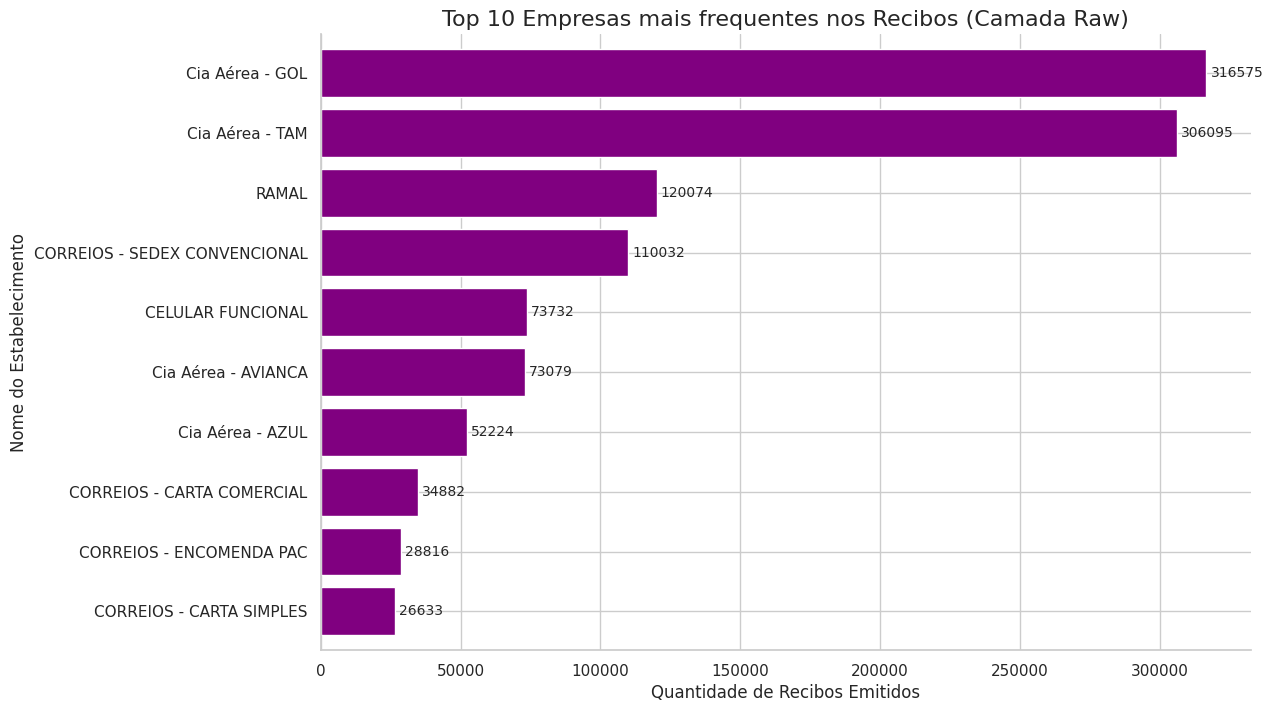

--- Diagnóstico de Fornecedores ---
Total de nomes distintos encontrados: 189.118
Se houver muitas variações do mesmo nome (ex: Uber vs Uber do Brasil), este número está inflado.


In [23]:
# Contagem de frequência
top_empresas = df['establishment_name'].value_counts().head(10).sort_values()

plt.figure(figsize=(12, 8))

# Plotagem
ax = top_empresas.plot(kind='barh', color='#800080', width=0.8)

plt.title('Top 10 Empresas mais frequentes nos Recibos (Camada Raw)', fontsize=16)
plt.xlabel('Quantidade de Recibos Emitidos', fontsize=12)
plt.ylabel('Nome do Estabelecimento', fontsize=12)

# Adiciona o número exato na ponta da barra
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

sns.despine()
plt.show()


# Mostra quantas empresas únicas existem. Se for um número gigante, confirma a sujeira.
total_empresas = df['establishment_name'].nunique()
print(f"--- Diagnóstico de Fornecedores ---")
print(f"Total de nomes distintos encontrados: {total_empresas:,}".replace(',', '.'))
print("Se houver muitas variações do mesmo nome (ex: Uber vs Uber do Brasil), este número está inflado.")